In [1]:
%load_ext autoreload
%autoreload 2

# Network Analysis

This notebook replicates the **Network Analysis** panel that was removed from the Dash webapp for performance reasons.
All interactive fields are plain Python variables — change them in the **Configuration** cell below, then re-run the cells you need.

In [2]:
import sys
from pathlib import Path

# Ensure the project root is on sys.path so we can import from visualize_webapp.
_PROJECT_ROOT = Path(".").resolve()
if str(_PROJECT_ROOT) not in sys.path:
	sys.path.insert(0, str(_PROJECT_ROOT))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import plotly.io as pio
from IPython.display import display

pio.renderers.default = "notebook"
# White backgrounds (app builders use transparent _style(); dark notebook themes need this)
pio.templates.default = "plotly_white"
import visualize_webapp.app as _vwa

# Save the real _style only once — re-running this cell must not alias the wrapper to itself.
if not hasattr(_vwa, "_style_original"):
	_vwa._style_original = _vwa._style


def _style_white_bg(fig, **kw):
	_vwa._style_original(fig, **kw)
	fig.update_layout(paper_bgcolor="white", plot_bgcolor="white")
	return fig


_vwa._style = _style_white_bg

from visualize_webapp.post_processing import (
	_pp_neuron_digit,
	_pp_dead,
	_pp_train_act,
)

from visualize_webapp.app import (
	scan_results,
	_metrics,
	_nts,
	_compact_neuron_label,
	_build_layer_inactive_count,
	_build_layer_digit_count_plot,
	_build_layer_digit_count_non_head_combined,
	_build_recovery_cumsum_plot,
	_build_dead_layer_traces,
	_build_dead_neuron_pre_nl_grid,
	_build_dead_neuron_inactivity_bar,
	_weights_sample_matrix,
)
from visualize_webapp.notebook.network_analysis_mpl import (
	mpl_dead_layer_traces,
	mpl_layer_digit_count_non_head_combined,
	mpl_layer_digit_count_plot,
	mpl_layer_inactive_count,
	mpl_neuron_assigned_digit_count_over_time,
	mpl_neuron_eval_activation_angle_over_time,
	mpl_neuron_eval_activation_mean_over_time,
	mpl_recovery_cumsum,
)
from visualize_webapp.post_processing import (
	per_neuron_recovery_counts,
	split_ever_dead_by_final_checkpoint,
)

## Configuration

Set the four identifiers below to select which run to analyse.
Run the **Discovery** cell first if you are unsure of the exact string values.

## Discovery

Run this cell to see every available experiment / model / run / optimizer combination.

In [3]:
tree = scan_results()
for eid, models in sorted(tree.items()):
	for mid, runs in sorted(models.items()):
		for rid, oids in sorted(runs.items()):
			for oid in oids:
				print(f"  experiment={eid!r}  model={mid!r}  run={rid!r}  optimizer={oid!r}")

  experiment='digit_ordered_0_1_75_25_tr100'  model='dnn_5x64'  run='0d4f4a'  optimizer='sgd_lr0.01'
  experiment='digit_ordered_0_1_75_25_tr100'  model='dnn_5x64'  run='0d4f4a'  optimizer='adagrad_lr0.01'
  experiment='digit_ordered_0_1_75_25_tr100'  model='dnn_5x64'  run='0d4f4a'  optimizer='adam_lr0.01'
  experiment='digit_ordered_0_1_75_25_tr100'  model='dnn_5x64'  run='0d4f4a'  optimizer='pure_shampoo_lr0.01'
  experiment='digit_ordered_0_1_75_25_tr100'  model='dnn_5x64'  run='0d4f4a'  optimizer='grafted_shampoo_lr0.01'
  experiment='pretrainK1000_tr100_then_0'  model='dnn_5x64'  run='6c35d5'  optimizer='sgd_lr0.01'
  experiment='pretrainK1000_tr100_then_0'  model='dnn_5x64'  run='6c35d5'  optimizer='adagrad_lr0.01'
  experiment='pretrainK1000_tr100_then_0'  model='dnn_5x64'  run='6c35d5'  optimizer='adam_lr0.01'
  experiment='pretrainK1000_tr100_then_0'  model='dnn_5x64'  run='6c35d5'  optimizer='pure_shampoo_lr0.01'
  experiment='pretrainK1000_tr100_then_0'  model='dnn_5x64'  ru

In [4]:
# __ CONFIG ____________________________________________________________
MODEL_ID	  = "dnn_5x64"
EXPERIMENT_ID = "pretrain_0_mislabel1_1_K1000_tr100" # trick to change the results dir from results/ to results_old/
RUN_ID		= "4a7338"
OPTIMIZER_ID  = "grafted_shampoo_lr0.01"

USE_BOXPLOT = False
# When True, sections above "Dead neuron detail" use matplotlib instead of Plotly.
USE_MATPLOTLIB = True


SHOW_PLOTS = True
# ____________________________________________________________________________


## Data loading

In [5]:
df_nd   = _pp_neuron_digit(EXPERIMENT_ID, MODEL_ID, OPTIMIZER_ID, rid=RUN_ID, w_cache=False)
df_dead = _pp_dead(EXPERIMENT_ID, MODEL_ID, OPTIMIZER_ID, rid=RUN_ID, w_cache=False)
metrics = _metrics(EXPERIMENT_ID, MODEL_ID, OPTIMIZER_ID, rid=RUN_ID, w_cache=False)
pp_ta   = _pp_train_act(EXPERIMENT_ID, MODEL_ID, OPTIMIZER_ID, rid=RUN_ID, w_cache=False)
nts	 = _nts(EXPERIMENT_ID, MODEL_ID, OPTIMIZER_ID, rid=RUN_ID, w_cache=False)

if df_nd is None or df_nd.empty:
	print("WARNING: post_processing_neuron_digit.csv not found for this run.")
	print("Re-run training to generate post-processing data.")
else:
	layer_order = list(dict.fromkeys(df_nd["layer_name"].tolist()))
	print(f"Layers: {layer_order}")

if df_dead is None or df_dead.empty:
	ever_dead_nids = []
	dead_at_end_nids = set()
	recovered_dead_nids = set()
	print("No dead-neuron data found.")
else:
	ever_dead_nids = sorted(df_dead[df_dead["is_dead"]]["neuron_id"].unique().tolist())
	dead_at_end_nids, recovered_dead_nids = split_ever_dead_by_final_checkpoint(df_dead)
	print(f"Dead neurons ({len(ever_dead_nids)}): {ever_dead_nids}")
	print(
		f"  Still dead at last checkpoint (perpetually dead at end): {len(dead_at_end_nids)}"
	)
	print(f"  Recovered dead (alive at last checkpoint): {len(recovered_dead_nids)}")

Layers: ['hidden.0', 'hidden.2', 'hidden.4', 'hidden.6', 'hidden.8', 'head']
Dead neurons (56): ['dnn|hidden.0|neuron|1', 'dnn|hidden.0|neuron|17', 'dnn|hidden.0|neuron|26', 'dnn|hidden.0|neuron|29', 'dnn|hidden.0|neuron|31', 'dnn|hidden.0|neuron|33', 'dnn|hidden.0|neuron|35', 'dnn|hidden.0|neuron|38', 'dnn|hidden.0|neuron|39', 'dnn|hidden.0|neuron|5', 'dnn|hidden.0|neuron|50', 'dnn|hidden.0|neuron|54', 'dnn|hidden.2|neuron|10', 'dnn|hidden.2|neuron|19', 'dnn|hidden.2|neuron|35', 'dnn|hidden.2|neuron|39', 'dnn|hidden.2|neuron|42', 'dnn|hidden.2|neuron|52', 'dnn|hidden.2|neuron|57', 'dnn|hidden.4|neuron|10', 'dnn|hidden.4|neuron|16', 'dnn|hidden.4|neuron|2', 'dnn|hidden.4|neuron|20', 'dnn|hidden.4|neuron|21', 'dnn|hidden.4|neuron|33', 'dnn|hidden.4|neuron|43', 'dnn|hidden.4|neuron|46', 'dnn|hidden.4|neuron|50', 'dnn|hidden.4|neuron|52', 'dnn|hidden.4|neuron|61', 'dnn|hidden.4|neuron|8', 'dnn|hidden.6|neuron|16', 'dnn|hidden.6|neuron|18', 'dnn|hidden.6|neuron|23', 'dnn|hidden.6|neuron|26

## Inactive neuron count per digit

One line chart per layer: how many neurons are inactive for each digit across checkpoints.

In [ ]:
if SHOW_PLOTS:
	if df_nd is not None and not df_nd.empty:
		for layer_name in layer_order:
			if USE_MATPLOTLIB:
				fig = mpl_layer_inactive_count(layer_name, df_nd, metrics)
				display(fig)
				plt.close(fig)
			else:
				fig = _build_layer_inactive_count(layer_name, df_nd, metrics)
				fig.show()
	else:
		print("No data — skipped.")

## Assigned digit count distribution

Boxplot per layer: distribution of the number of digits a neuron is *assigned* to, across checkpoints.

In [ ]:
if SHOW_PLOTS:
	if df_nd is not None and not df_nd.empty:
		for layer_name in layer_order:
			if USE_MATPLOTLIB:
				fig = mpl_layer_digit_count_plot(
					layer_name, df_nd, metrics, "assigned", "Assigned", boxplot=USE_BOXPLOT
				)
				display(fig)
				plt.close(fig)
			else:
				fig = _build_layer_digit_count_plot(
					layer_name, df_nd, metrics, "assigned", "Assigned", boxplot=USE_BOXPLOT
				)
				fig.show()
		if not USE_BOXPLOT:
			if USE_MATPLOTLIB:
				fig = mpl_layer_digit_count_non_head_combined(
					df_nd, metrics, layer_order, "assigned", "Assigned"
				)
				display(fig)
				plt.close(fig)
			else:
				fig = _build_layer_digit_count_non_head_combined(
					df_nd, metrics, layer_order, "assigned", "Assigned"
				)
				fig.show()
	else:
		print("No data — skipped.")

## Inactive digit count distribution

Boxplot per layer: distribution of the number of digits a neuron is *inactive* for, across checkpoints.

In [ ]:
if SHOW_PLOTS:
	if df_nd is not None and not df_nd.empty:
		for layer_name in layer_order:
			if USE_MATPLOTLIB:
				fig = mpl_layer_digit_count_plot(
					layer_name, df_nd, metrics, "inactive", "Inactive", boxplot=USE_BOXPLOT
				)
				display(fig)
				plt.close(fig)
			else:
				fig = _build_layer_digit_count_plot(
					layer_name, df_nd, metrics, "inactive", "Inactive", boxplot=USE_BOXPLOT
				)
				fig.show()
		if not USE_BOXPLOT:
			if USE_MATPLOTLIB:
				fig = mpl_layer_digit_count_non_head_combined(
					df_nd, metrics, layer_order, "inactive", "Inactive"
				)
				display(fig)
				plt.close(fig)
			else:
				fig = _build_layer_digit_count_non_head_combined(
					df_nd, metrics, layer_order, "inactive", "Inactive"
				)
				fig.show()
	else:
		print("No data — skipped.")

## Dead neuron traces

For each layer: one trace per neuron — inactive-digit count over time.

- **Perpetually dead** (still dead at the **last** checkpoint): matches `is_ppd` at the end of training when that column exists.
- **Recovered dead**: were `is_dead` at some earlier checkpoint but **not** dead at the last checkpoint.

### Perpetually dead (still dead at last checkpoint)

In [ ]:
if SHOW_PLOTS:
	if df_dead is not None and not df_dead.empty and len(dead_at_end_nids) > 0:
		for layer_name in layer_order:
			layer_has = (
				(df_dead["layer_name"] == layer_name)
				& df_dead["is_dead"]
				& df_dead["neuron_id"].astype(str).isin(dead_at_end_nids)
			).any()
			if layer_has:
				if USE_MATPLOTLIB:
					fig = mpl_dead_layer_traces(
						layer_name,
						df_nd,
						df_dead,
						metrics,
						neuron_ids=dead_at_end_nids,
						title="Perpetually dead neurons",
						empty_message="No perpetually dead neurons in this layer.",
					)
					display(fig)
					plt.close(fig)
				else:
					fig = _build_dead_layer_traces(
						layer_name,
						df_nd,
						df_dead,
						metrics,
						neuron_ids=dead_at_end_nids,
						title="Perpetually dead neurons",
						empty_message="No perpetually dead neurons in this layer.",
					)
					fig.show()
	else:
		print("No perpetually dead neurons — skipped.")

### Recovered dead (alive at last checkpoint)

In [ ]:
if SHOW_PLOTS:
	if df_dead is not None and not df_dead.empty and len(recovered_dead_nids) > 0:
		for layer_name in layer_order:
			layer_has = (
				(df_dead["layer_name"] == layer_name)
				& df_dead["is_dead"]
				& df_dead["neuron_id"].astype(str).isin(recovered_dead_nids)
			).any()
			if layer_has:
				if USE_MATPLOTLIB:
					fig = mpl_dead_layer_traces(
						layer_name,
						df_nd,
						df_dead,
						metrics,
						neuron_ids=recovered_dead_nids,
						title="Recovered dead neurons",
						empty_message="No recovered dead neurons in this layer.",
					)
					display(fig)
					plt.close(fig)
				else:
					fig = _build_dead_layer_traces(
						layer_name,
						df_nd,
						df_dead,
						metrics,
						neuron_ids=recovered_dead_nids,
						title="Recovered dead neurons",
						empty_message="No recovered dead neurons in this layer.",
					)
					fig.show()
	else:
		print("No recovered dead neurons — skipped.")

## Dead neuron detail

Set `DEAD_NEURON_ID` in the **Configuration** cell to one of the full IDs from the **Data loading** cell (or from the list below). Plot titles and legends use the compact form `<layer>:<index>` (e.g. `h0:16`).

Available neurons printed below for convenience:

In [11]:
print("Available dead neuron IDs (compact label — use full string for DEAD_NEURON_ID):")
for nid in ever_dead_nids:
	print(f"  {_compact_neuron_label(nid):12}  {nid!r}")

Available dead neuron IDs (compact label — use full string for DEAD_NEURON_ID):
  h0:1          'dnn|hidden.0|neuron|1'
  h0:17         'dnn|hidden.0|neuron|17'
  h0:26         'dnn|hidden.0|neuron|26'
  h0:29         'dnn|hidden.0|neuron|29'
  h0:31         'dnn|hidden.0|neuron|31'
  h0:33         'dnn|hidden.0|neuron|33'
  h0:35         'dnn|hidden.0|neuron|35'
  h0:38         'dnn|hidden.0|neuron|38'
  h0:39         'dnn|hidden.0|neuron|39'
  h0:5          'dnn|hidden.0|neuron|5'
  h0:50         'dnn|hidden.0|neuron|50'
  h0:54         'dnn|hidden.0|neuron|54'
  h2:10         'dnn|hidden.2|neuron|10'
  h2:19         'dnn|hidden.2|neuron|19'
  h2:35         'dnn|hidden.2|neuron|35'
  h2:39         'dnn|hidden.2|neuron|39'
  h2:42         'dnn|hidden.2|neuron|42'
  h2:52         'dnn|hidden.2|neuron|52'
  h2:57         'dnn|hidden.2|neuron|57'
  h4:10         'dnn|hidden.4|neuron|10'
  h4:16         'dnn|hidden.4|neuron|16'
  h4:2          'dnn|hidden.4|neuron|2'
  h4:20         'dnn|

## Cumulative recoveries (hidden layers)

One line per hidden layer: cumulative count of **recovery** events (neuron was `is_dead` at checkpoint *i* and not dead at *i+1*). The output layer (`head`) is omitted. Values are recomputed from `df_dead` when you run the cell.

In [ ]:
if SHOW_PLOTS:
	if df_dead is not None and not df_dead.empty:
		if USE_MATPLOTLIB:
			fig = mpl_recovery_cumsum(df_dead, metrics, layer_order)
			plt.show()
		else:
			fig = _build_recovery_cumsum_plot(df_dead, metrics, layer_order)
			fig.show()
	else:
		print("No dead-neuron table — skipped.")

In [ ]:
# Hidden-layer neurons that were ever dead: those with at most one dead→alive transition.
_rc, _ = per_neuron_recovery_counts(df_dead, layer_order) if df_dead is not None else ({}, {})
if df_dead is None or df_dead.empty:
	ever_dead_hidden: set[str] = set()
else:
	hid = df_dead["layer_name"].astype(str) != "head"
	dm = pd.Series(df_dead["is_dead"]).fillna(False)
	if dm.dtype == object:
		dead_m = dm.astype(str).str.lower().isin(("true", "1", "t"))
	else:
		dead_m = dm.astype(bool)
	ever_dead_hidden = {
		str(x)
		for x in df_dead.loc[hid & dead_m, "neuron_id"].tolist()
	}
_at_most_1 = sorted(
	(nid, c) for nid, c in _rc.items() if c <= 1 and nid in ever_dead_hidden
)
print(
	f"Hidden neurons that were dead at some point and have <=1 recovery ({len(_at_most_1)} of {len(ever_dead_hidden)} dead hidden):"
)
for nid, c in _at_most_1:
	print(f"  {c} recovery/recoveries: {_compact_neuron_label(nid)} — {nid}")

In [ ]:
ppd = pd.Series(df_dead["is_ppd"]).fillna(False)
ppd_m = ppd.astype(str).str.lower().isin(("true", "1", "t"))
ppd__hidden = {
		str(x) for x in df_dead.loc[hid & ppd_m, "neuron_id"].tolist()
}
_at_most_1_ppd = sorted(
	(nid, c) for nid, c in _rc.items() if c <= 1 and nid in ppd__hidden
)
print(
	f"Hidden neurons that are perpetually dead <=1 recovery ({len(_at_most_1_ppd)} of {len(ppd__hidden)} perpetually dead):"
)
for nid, c in _at_most_1_ppd:
	print(f"  {c} recovery/recoveries: {_compact_neuron_label(nid)} — {nid}")

In [ ]:
# Neurons which are *not* PPD and have exactly 1 recovery

# Calculate set of hidden neurons which are NOT perpetually dead (not PPD)
not_ppd__hidden = ever_dead_hidden - ppd__hidden

# Find those with exactly 1 recovery
exactly_1_non_ppd = sorted(
	(nid, c) for nid, c in _rc.items() if c == 1 and nid in not_ppd__hidden
)

print(
	f"Hidden neurons that are NOT perpetually dead and have exactly 1 recovery ({len(exactly_1_non_ppd)} of {len(not_ppd__hidden)} non-PPD hidden):"
)
for nid, c in exactly_1_non_ppd:
	print(f"  {c} recovery: {_compact_neuron_label(nid)} — {nid}")

In [ ]:
from visualize_webapp.app import _NETWORK_SAMPLES_PER_DIGIT

if df_nd is None or df_nd.empty or df_dead is None or df_dead.empty:
	reassigned_neuron_ids = []
	df_reassigned_summary = pd.DataFrame()
	print("No neuron-digit or dead-neuron data — skipped.")
else:
	first_dead = (
		df_dead.loc[df_dead["is_dead"], ["neuron_id", "checkpoint_idx"]]
		.groupby("neuron_id", sort=False)["checkpoint_idx"]
		.min()
		.rename("first_dead_checkpoint")
	)
	assigned = df_nd.loc[
		df_nd["status"] == "assigned",
		["neuron_id", "layer_name", "checkpoint_idx", "digit"],
	]
	merged = assigned.merge(first_dead.reset_index(), on="neuron_id", how="inner")
	after_dead = merged[merged["checkpoint_idx"] > merged["first_dead_checkpoint"]]

	reassigned_neuron_ids = sorted(after_dead["neuron_id"].unique().tolist())

	if after_dead.empty:
		df_reassigned_summary = pd.DataFrame()
	else:
		first_reassign_cp = after_dead.groupby("neuron_id", sort=False)["checkpoint_idx"].min()
		fr = first_reassign_cp.rename("first_reassign_checkpoint").reset_index()
		at_first = after_dead.merge(
			fr,
			left_on=["neuron_id", "checkpoint_idx"],
			right_on=["neuron_id", "first_reassign_checkpoint"],
		)
		digits_col = (
			at_first.groupby(["neuron_id", "layer_name", "first_reassign_checkpoint"], sort=False)["digit"]
			.apply(lambda s: ",".join(map(str, sorted(s.unique()))))
			.reset_index(name="digits_at_first_reassign")
		)
		df_reassigned_summary = digits_col.merge(
			first_dead.reset_index(), on="neuron_id", how="left"
		)
		df_reassigned_summary.insert(
			0,
			"compact",
			df_reassigned_summary["neuron_id"].map(_compact_neuron_label),
		)
		df_reassigned_summary = df_reassigned_summary.sort_values(
			["layer_name", "first_reassign_checkpoint", "compact"],
			kind="stable",
		)

	print(
		f"K_SAMPLES={_NETWORK_SAMPLES_PER_DIGIT} "
		"(assigned means all K post-nl activations > 0 for that digit).\n"
		f"Reassigned neurons: {len(reassigned_neuron_ids)}"
	)
	if not df_reassigned_summary.empty:
		display(df_reassigned_summary)


In [17]:
# Config 2 


# Set to the full neuron_id string (e.g. "dnn|hidden.0|neuron|42"); else None to skip
DEAD_NEURON_ID = "dnn|hidden.4|neuron|46"

### Pre-NL activation grid

2×5 subplots — mean pre-nonlinearity activation over training iterations, one panel per digit.
Y-axis is forced to end at 0 to highlight how the neuron dies.

In [ ]:
# if SHOW_PLOTS:
if DEAD_NEURON_ID is not None:
	fig = _build_dead_neuron_pre_nl_grid(
		DEAD_NEURON_ID, EXPERIMENT_ID, MODEL_ID, OPTIMIZER_ID, rid=RUN_ID
	)
	fig.show()
else:
	print("DEAD_NEURON_ID is None — set it in the Configuration cell to render this plot.")

### Inactivity ratio on full training set

Bar chart: fraction of training samples that produce zero post-ReLU activation, per digit.

In [ ]:
if DEAD_NEURON_ID is not None:
	if pp_ta:
		fig = _build_dead_neuron_inactivity_bar(DEAD_NEURON_ID, pp_ta)
		fig.show()
	else:
		print("post_processing_train_act.npz not found for this run — bar chart unavailable.")
else:
	print("DEAD_NEURON_ID is None — set it in the Configuration cell to render this plot.")

In [ ]:
MAX_ANGLE = 25


cp = df_reassigned_summary.loc[
	df_reassigned_summary["neuron_id"] == DEAD_NEURON_ID
]["first_reassign_checkpoint"].item()

if DEAD_NEURON_ID is None:
	print("Set DEAD_NEURON_ID in the Configuration cell.")
elif df_dead is None or df_dead.empty or not layer_order:
	print("No dead-neuron data or layer_order — skipped.")
else:
	nid_key = str(DEAD_NEURON_ID)
	_rc_here, _rc_here_cp = per_neuron_recovery_counts(df_dead, layer_order)
	print(
		f"{_compact_neuron_label(DEAD_NEURON_ID)}  full_id={DEAD_NEURON_ID!r}  "
		f"recovery_count={_rc_here.get(nid_key, 0)}  "
		f"recovery_checkpoint_idx={_rc_here_cp.get(nid_key, [])}"
	)

	if df_nd is not None and not df_nd.empty:
		fig = mpl_neuron_assigned_digit_count_over_time(DEAD_NEURON_ID, df_nd, metrics)
		display(fig)
		plt.close(fig)
	else:
		print("No neuron-digit data — skipped assigned-digit plot.")

	if nts:
		fig = mpl_neuron_eval_activation_mean_over_time(DEAD_NEURON_ID, nts, metrics)
		display(fig)
		plt.close(fig)
		fig = mpl_neuron_eval_activation_angle_over_time(DEAD_NEURON_ID, nts, metrics,signed_angle_y_deg_limit=MAX_ANGLE, min_idx = 3000, cp=cp)
		display(fig)
		plt.close(fig)
	else:
		print("No neuron_timeseries.npz — skipped activation / angle plots.")


In [21]:
w = _weights_sample_matrix(nts,DEAD_NEURON_ID)

In [ ]:

import numpy as np
import matplotlib.pyplot as plt

low_hundred, top_hundred = cp//100*100, (cp//100+1)*100

# Data
W_slice = w[low_hundred:top_hundred, :]
delta_W = np.diff(W_slice, axis=0)

x_w = np.arange(low_hundred, top_hundred)
x_dw = np.arange(low_hundred, top_hundred - 1)

magnitudes = np.max(np.abs(W_slice), axis=0)
sorted_idx = np.argsort(magnitudes)[::-1]  # descending

# Plot
fig, axes = plt.subplots(8, 8, figsize=(16, 16), sharey=True)
axes = axes.flatten()

for plot_i, weight_i in enumerate(sorted_idx):
	ax = axes[plot_i]
	
	# ΔW (shared axis)
	dw_plot = ax.plot(x_dw, delta_W[:, weight_i], color='tab:blue', label='ΔW (delta)')
	
	# W (secondary axis)
	ax2 = ax.twinx()
	w_plot = ax2.plot(x_w, W_slice[:, weight_i], color='tab:red', alpha=0.7, label='W (weight)')
	
	ax.axvline(x=cp, color='k', linestyle='--', linewidth=1)
	
	ax.set_title(f'W{weight_i} |m|={magnitudes[weight_i]:.2e}', fontsize=8)


handles1, labels1 = axes[0].get_legend_handles_labels()
handles2, labels2 = axes[0].get_shared_x_axes().get_siblings(axes[0])[0].get_legend_handles_labels()
fig.legend(
    handles1 + handles2,
    [l for l in labels1 + labels2 if l],
    loc='upper center',
    ncol=2,
    bbox_to_anchor=(0.5, 1.02),
    fontsize=12,
)
fig.suptitle(f'{DEAD_NEURON_ID=} (incoming) weights and weight changes surrounding recovery point, ordered by magnitude', y=1.04)

plt.tight_layout()
plt.show()

In [ ]:
reassigned_neuron_ids

In [ ]:
a = after_dead.groupby(by=["neuron_id"])['checkpoint_idx'].min()
a.reset_index()

In [ ]:
df_nd.head()

In [ ]:
a = after_dead.groupby(by=["neuron_id"])['checkpoint_idx'].min()
a

In [ ]:
reassigned_after_dead = df_nd.merge(
	after_dead.groupby(by=["neuron_id"])['checkpoint_idx'].min().reset_index(),
	on=["neuron_id", "checkpoint_idx"],
	how="inner"
).groupby(["neuron_id","digit"])["status"].first().reset_index().set_index(["neuron_id","digit"])
K_SAMPLES = 5
reassigned_after_dead.groupby("neuron_id")["status"].apply(lambda s: ((s == "inactive").sum(),*((s == f'partial_{k}').sum() for k in range(1,K_SAMPLES)),(s == "assigned").sum() ))

In [28]:
from models.unit_node_id import parse_unit_node_id
from models import AnalyzableModel
from torch import Tensor
import torch
import torch.nn as nn
from torch.autograd import Function

# Adapted from github.com/jacobgil/pytorch-grad-cam/blob/master/pytorch_grad_cam/guided_backprop.py
class _GBPReLU(Function):
    @staticmethod
    def forward(ctx, x):
        ctx.save_for_backward(x)
        return x.clamp(min=0)

    @staticmethod
    def backward(ctx, grad_output):
        (x,) = ctx.saved_tensors
        return grad_output * (x > 0).type_as(grad_output) * (grad_output > 0).type_as(grad_output)


class _GBPReLUModule(nn.Module):
    def forward(self, x):
        return _GBPReLU.apply(x)


def _replace_layers(module, src_type, make_replacement):
    for name, child in module._modules.items():
        if isinstance(child, src_type):
            module._modules[name] = make_replacement()
        else:
            _replace_layers(child, src_type, make_replacement)


def get_neuron_effective_receptive_field(
    model: AnalyzableModel, neuron_id, eval_digits, device, use_gbp: bool = False
):
    parsed_node_id = parse_unit_node_id(neuron_id)
    assert parsed_node_id is not None
    model.eval()

    captured = []

    def _hook(module, args, forward_output: Tensor):
        captured.append(forward_output)

    hook = model.hookable_layers()[parsed_node_id['layer_name']].register_forward_hook(_hook)

    def _to_batched(x: Tensor) -> Tensor:
        x = x.detach().to(device=device)
        if x.dim() == 3:
            x = x.unsqueeze(0)
        return x

    flattened_batches = []
    for image in eval_digits:
        x = _to_batched(image if isinstance(image, Tensor) else torch.as_tensor(image))
        for i in range(x.size(0)):
            flattened_batches.append(x[i : i + 1])

    def _get_one_grad(x1: Tensor) -> Tensor:
        x1 = x1.detach().requires_grad_(True)
        captured.clear()
        model(x1)
        assert len(captured) == 1
        h = captured[0]
        y = h[0, parsed_node_id['unit_index']]
        (g,) = torch.autograd.grad(y, x1, retain_graph=False, create_graph=False)
        return g.clone().detach().cpu()

    if use_gbp:
        _replace_layers(model, nn.ReLU, _GBPReLUModule)

    try:
        gradients = []
        for image in flattened_batches:
            gradients.append(_get_one_grad(image).squeeze())
    finally:
        hook.remove()
        if use_gbp:
            _replace_layers(model, _GBPReLUModule, nn.ReLU)
        model.train()

    return gradients

In [29]:
import json
from pathlib import Path

import torch

from compute_results.config_guard import load_initial_model_state_dict

PROJECT_ROOT = Path("../../").resolve()

OPTIMIZER_PREFIX_TO_REGISTRY_CLASS = {
    "sgd": "SGDExtractor",
    "adam": "AdamExtractor",
    "adagrad": "AdaGradExtractor",
    "pure_shampoo": "PureShampooExtractor",
    "grafted_shampoo": "GraftedShampooExtractor",
    "graft_shampoo": "GraftedShampooExtractor",
}


def registry_class_from_optimizer_id(optimizer_id: str) -> str:
    if "_lr" not in optimizer_id:
        raise ValueError(f"unexpected optimizer_id shape: {optimizer_id!r}")
    prefix = optimizer_id.rsplit("_lr", 1)[0]
    try:
        return OPTIMIZER_PREFIX_TO_REGISTRY_CLASS[prefix]
    except KeyError as e:
        raise KeyError(f"unknown optimizer_id prefix {prefix!r}") from e


cfg_path = PROJECT_ROOT / "results" / EXPERIMENT_ID / RUN_ID / MODEL_ID / "config.json"
config = json.loads(cfg_path.read_text(encoding="utf-8"))
raw = (config.get("use_initial_model") or "").strip()
if not raw:
    raise ValueError(f"use_initial_model missing or empty in {cfg_path}")

init_path = (PROJECT_ROOT / raw).resolve()
assert init_path.is_dir(), f"Model bundle dir not found at {init_path}"
registry_optimizer_class = registry_class_from_optimizer_id(OPTIMIZER_ID)

state = load_initial_model_state_dict(
    str(init_path),
    registry_class_name=registry_optimizer_class,
)

In [30]:
from models.dnn_5_hidden_64 import DNN5Hidden64
from models.cnn_3conv_k5_out32_then_fc32 import CNN3ConvK5Out32FC32
import torch
from experiments.mnist import MNISTWrapper

model = DNN5Hidden64() if "dnn" in MODEL_ID else CNN3ConvK5Out32FC32()
device = next(iter(model.parameters())).device
model.load_state_dict(state)

class DummyExp(MNISTWrapper):
	def experiment_id(self):
		return ""
	def _build_trials(self, batch_size: int, seed: int, *, num_experiment_runs: int) :
		return []

eval_digits = DummyExp().evaluation_inputs(device)[0]

In [31]:
gds = get_neuron_effective_receptive_field(model, DEAD_NEURON_ID, eval_digits,device)
len(gds)

50

In [32]:
from scipy.stats import multivariate_normal
def gaussian_from_grad(matrix: np.ndarray | torch.Tensor) -> np.ndarray:
	"""
	Fits a 2D Gaussian to a matrix using its mean and covariance,
	then evaluates it on the same grid.
	
	Returns an array with the same shape as the input of the Gaussian density values.
	"""
	matrix = matrix if isinstance(matrix, np.ndarray) else matrix.cpu().numpy()
	matrix = np.abs(matrix)
	h, w = matrix.shape
	ys, xs = np.meshgrid(np.arange(h), np.arange(w), indexing="ij")
	coords = np.stack([ys.ravel(), xs.ravel()], axis=1).astype(float)  # (h*w, 2)
	weights = matrix.ravel()
	weights_sum = weights.sum()
	if weights_sum == 0:
		raise ValueError("Matrix sums to zero — cannot compute a weighted mean/cov.")
	weights = weights / weights_sum  # normalize to get distribution
	# Weighted mean: shape (2,)
	mean = (weights[:, None] * coords).sum(axis=0)
	# Weighted covariance: shape (2, 2)
	diff = coords - mean  # (h*w, 2)
	cov = (weights[:, None] * diff).T @ diff  # (2, 2)
	# Evaluate the Gaussian on the same grid
	rv = multivariate_normal(mean=mean, cov=cov)
	gaussian = rv.pdf(coords).reshape(h, w)
	return gaussian  * weights_sum


In [33]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm, colors


def _global_min_max(arrs):
	lo = min(float(a.min()) for a in arrs)
	hi = max(float(a.max()) for a in arrs)
	if not np.isfinite(lo) or not np.isfinite(hi) or lo == hi:
		return 0.0, 1.0
	return lo, hi


def plot_gradient_heatmaps(
	gradients,
	*,
	n_digits=10,
	n_samples=5,
	cmap="RdBu",
	use_gaussian=False,
):
	"""
	Returns two figures:
	  1) grid of per-sample gradient maps
	  2) per-digit mean maps
	"""
	total = n_digits * n_samples
	if len(gradients) < total:
		raise ValueError(f"Expected {total} gradients, got {len(gradients)}")

	mats = [gradients[i] for i in range(total)]
	vmin, vmax = _global_min_max(mats)
	
	mm = max(abs(vmin), abs(vmax))
	vmin, vmax = -mm, mm

	plt.rcParams.update({
		"font.size": 9,
		"axes.titlesize": 10,
		"axes.labelsize": 8,
	})

	# =========================================================
	# Figure 1: grid
	# =========================================================
	fig1, axes1 = plt.subplots(
		n_digits,
		n_samples,
		figsize=(2.2 * n_samples, 1.9 * n_digits),
		constrained_layout=True,
	)

	for d in range(n_digits):
		for s in range(n_samples):
			ax = axes1[d, s]
			img = mats[d * n_samples + s]
			if use_gaussian:
				img = gaussian_from_grad(img)

			im = ax.imshow(
				img,
				cmap=cmap,
				vmin=vmin,
				vmax=vmax,
				interpolation="nearest",
			)

			# minimal, clean titles
			if d == 0:
				ax.set_title(f"s={s}")
			if s == 0:
				ax.set_ylabel(f"{d}", rotation=0, labelpad=10, va="center")

			ax.set_xticks([])
			ax.set_yticks([])

	fig1.suptitle("Gradient maps per digit / sample", fontsize=12)

	cbar = fig1.colorbar(
		cm.ScalarMappable(norm=colors.Normalize(vmin, vmax), cmap=cmap),
		ax=axes1,
		shrink=0.6,
		location="right",
	)
	cbar.set_label("intensity")

	# =========================================================
	# Figure 2: mean per digit
	# =========================================================
	means = []
	for d in range(n_digits):
		stack = np.stack(
			[mats[d * n_samples + s] for s in range(n_samples)],
			axis=0,
		)
		means.append(stack.mean(0))

	mn, mx = _global_min_max(means)
	mm = max(abs(mn), abs(mx))
	mn, mx = -mm, mm

	fig2, axes2 = plt.subplots(
		5, 2,
		figsize=(6, 10),
		constrained_layout=True,
	)

	for d in range(n_digits):
		r, c = divmod(d, 2)
		ax = axes2[r, c]

		img = means[d]
		if use_gaussian:
			img = gaussian_from_grad(img)

		ax.imshow(
			img,
			cmap=cmap,
			vmin=mn,
			vmax=mx,
			interpolation="nearest",
		)

		ax.set_title(f"digit {d}")
		ax.set_xticks([])
		ax.set_yticks([])

	fig2.suptitle(f"Mean gradient map per digit (n={n_samples})", fontsize=12)

	cbar2 = fig2.colorbar(
		cm.ScalarMappable(norm=colors.Normalize(mn, mx), cmap=cmap),
		ax=axes2,
		shrink=0.7,
		location="right",
	)
	cbar2.set_label("mean intensity")

	return (fig1, axes1), (fig2, axes2)

((<Figure size 1100x1900 with 51 Axes>,
  array([[<Axes: title={'center': 's=0'}, ylabel='0'>,
          <Axes: title={'center': 's=1'}>, <Axes: title={'center': 's=2'}>,
          <Axes: title={'center': 's=3'}>, <Axes: title={'center': 's=4'}>],
         [<Axes: ylabel='1'>, <Axes: >, <Axes: >, <Axes: >, <Axes: >],
         [<Axes: ylabel='2'>, <Axes: >, <Axes: >, <Axes: >, <Axes: >],
         [<Axes: ylabel='3'>, <Axes: >, <Axes: >, <Axes: >, <Axes: >],
         [<Axes: ylabel='4'>, <Axes: >, <Axes: >, <Axes: >, <Axes: >],
         [<Axes: ylabel='5'>, <Axes: >, <Axes: >, <Axes: >, <Axes: >],
         [<Axes: ylabel='6'>, <Axes: >, <Axes: >, <Axes: >, <Axes: >],
         [<Axes: ylabel='7'>, <Axes: >, <Axes: >, <Axes: >, <Axes: >],
         [<Axes: ylabel='8'>, <Axes: >, <Axes: >, <Axes: >, <Axes: >],
         [<Axes: ylabel='9'>, <Axes: >, <Axes: >, <Axes: >, <Axes: >]],
        dtype=object)),
 (<Figure size 600x1000 with 11 Axes>,
  array([[<Axes: title={'center': 'digit 0'}>,
  

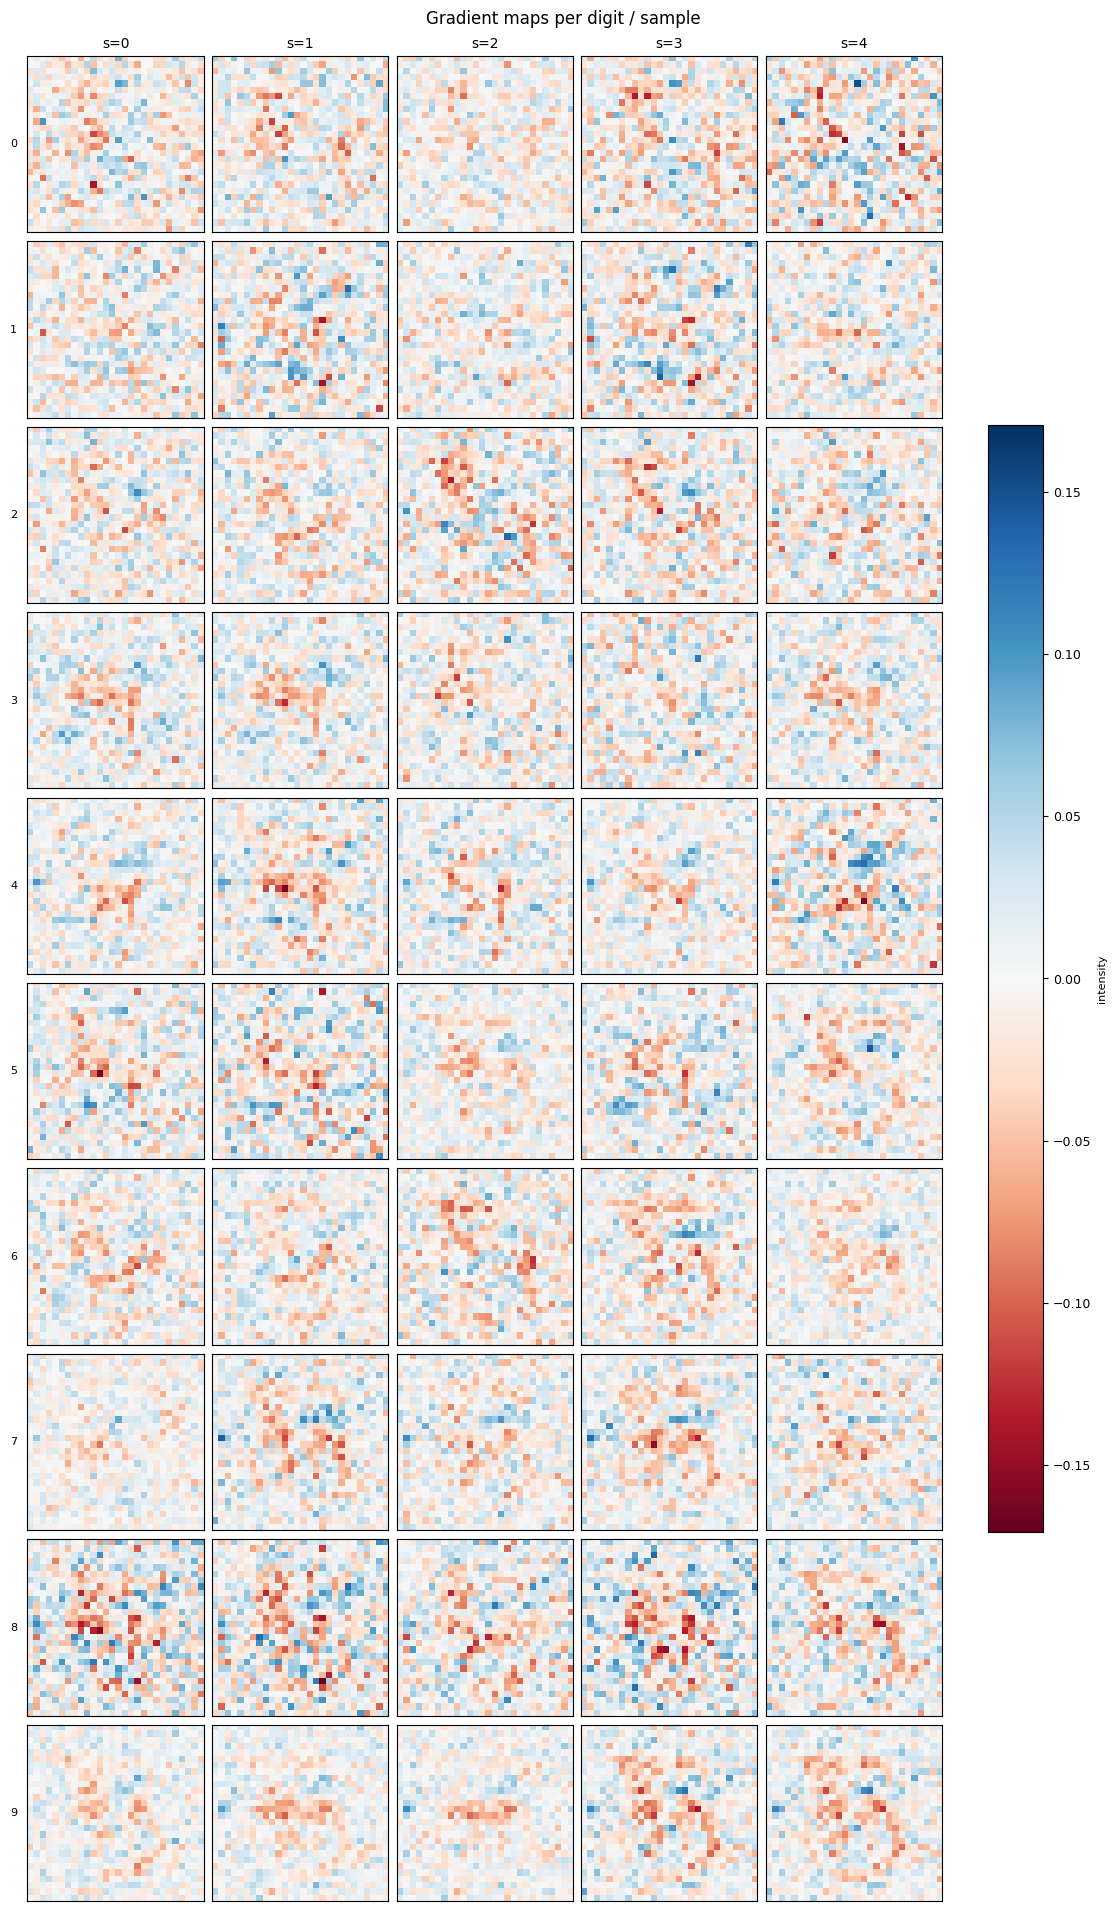

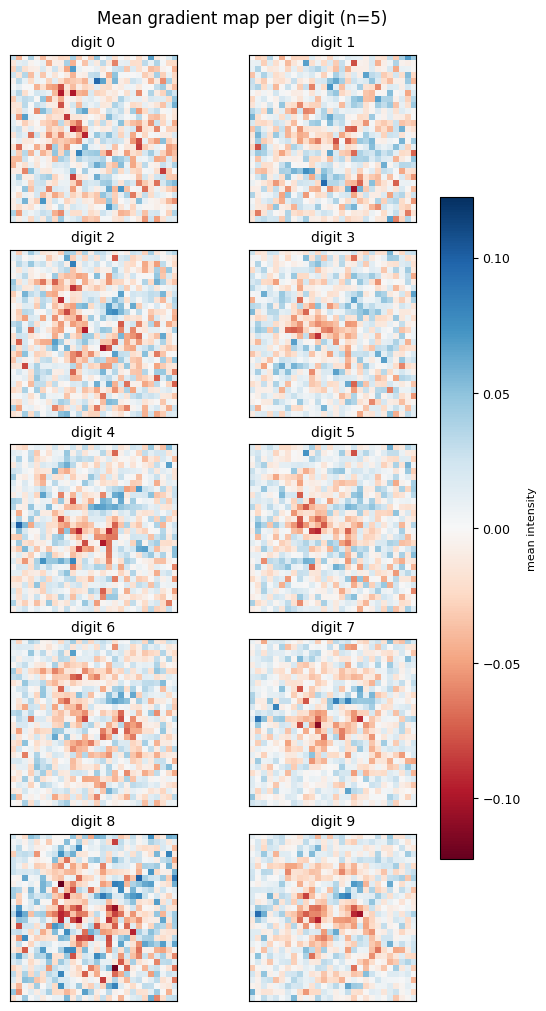

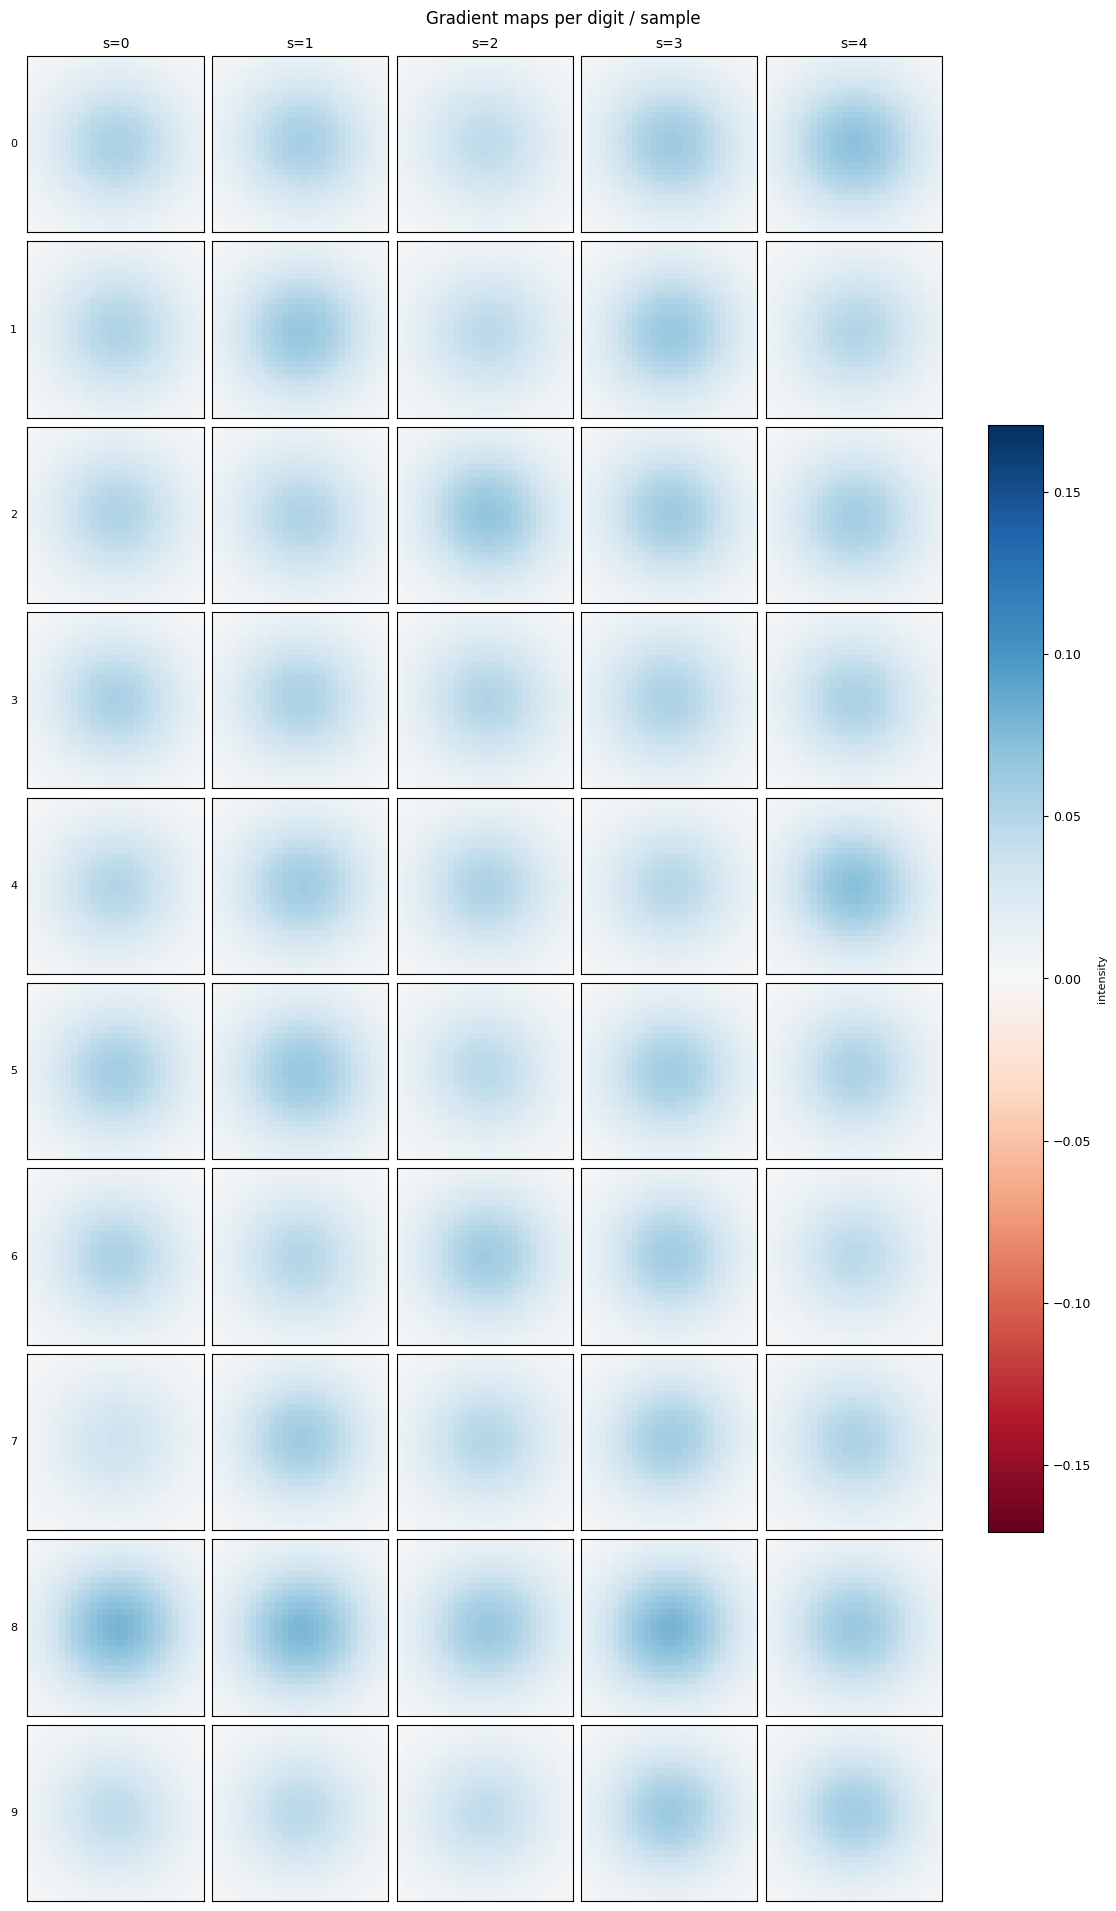

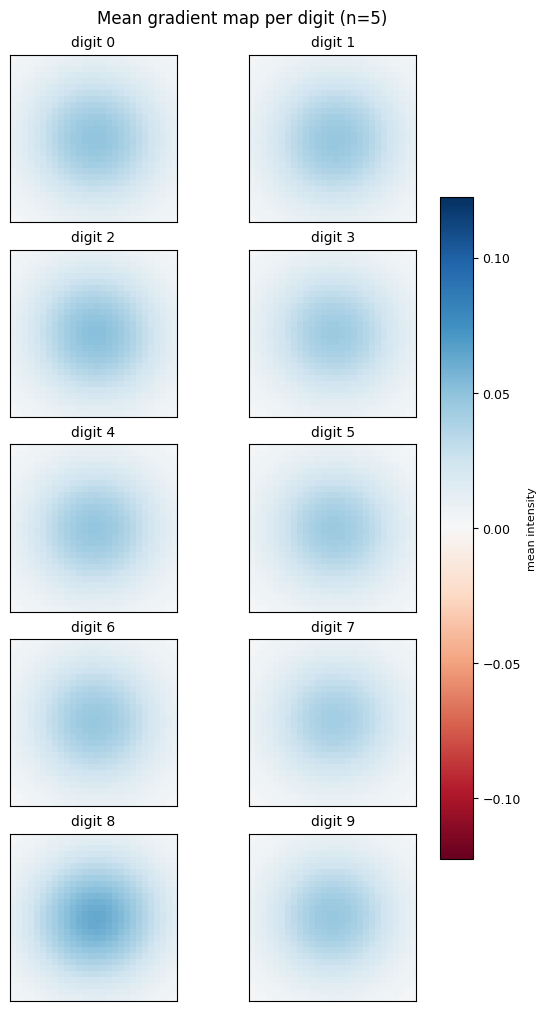

In [34]:
plot_gradient_heatmaps(gds)
plot_gradient_heatmaps(gds, use_gaussian=True)

In [35]:
recovery_periods

NameError: name 'recovery_periods' is not defined

In [ ]:
def custom_gds(nts, dead_neuron_id, recovery_periods):
	

In [ ]:
gds_gbp = get_neuron_effective_receptive_field(model, DEAD_NEURON_ID, eval_digits,device, use_gbp=True)

In [ ]:
plot_gradient_heatmaps(gds_gbp)
plot_gradient_heatmaps(gds_gbp, use_gaussian=True)

In [ ]:
w.shape

In [ ]:
def plot_weight_column(w, cp, n_rows=64, cmap="RdBu"):
    """
    Visualize w[cp] as a (64, 1) heatmap with larger squares and legend.
    """
    arr = np.asarray(w[cp]).reshape(n_rows, 1)
    # Make figure tall enough so each cell appears large
    fig_h = max(8, n_rows * 0.25)
    fig, ax = plt.subplots(figsize=(3, fig_h), dpi=140)
    im = ax.imshow(
        arr,
        cmap=cmap,
        aspect="equal",          # square-ish cells
        interpolation="nearest"  # crisp block edges
    )
    ax.set_title(f"Weight map for cp={cp}", pad=10)
    ax.set_xlabel("Channel")
    ax.set_ylabel("Index")
    # Keep x-axis minimal for a single column
    ax.set_xticks([0])
    ax.set_xticklabels(["w[cp]"])
    # Optional: add subtle gridlines around cells
    ax.set_yticks(np.arange(-0.5, n_rows, 1), minor=True)
    ax.set_xticks(np.arange(-0.5, 1, 1), minor=True)
    ax.grid(which="minor", color="white", linestyle="-", linewidth=0.5, alpha=0.6)
    ax.tick_params(which="minor", bottom=False, left=False)
    # Color legend
    cbar = fig.colorbar(
        im,
        ax=ax,
        orientation="horizontal",
        location="top",     # puts it above the axes
        fraction=0.06,
        pad=0.02,
    )

    cbar.set_label("Weight value", rotation=270, labelpad=12)
    plt.tight_layout()
    plt.show()

plot_weight_column(w, cp)

In [ ]:
from models.unit_node_id import parse_unit_node_id, format_unit_node_id
import torch.nn as nn
from tqdm import tqdm

def get_all_prev_layer_neuron_erfs(
    model: AnalyzableModel,
    target_neuron_id: str,
    eval_digits,
    device,
    use_gbp: bool = False,
):
    """
    Compute input gradients (effective receptive fields) for ALL neurons
    in the layer immediately before `target_neuron_id`.

    Returns:
        dict[str, list[Tensor]]:
            {
              prev_neuron_node_id: [grad_for_img0, grad_for_img1, ...],
              ...
            }
    """
    parsed = parse_unit_node_id(target_neuron_id)
    assert parsed is not None, f"Invalid node id: {target_neuron_id}"

    hookable = model.hookable_layers()
    layer_names = list(hookable.keys())

    cur_layer = parsed["layer_name"]
    assert cur_layer in hookable, f"Layer {cur_layer} not in hookable layers"

    cur_idx = layer_names.index(cur_layer)
    if cur_idx == 0:
        raise ValueError(
            f"{target_neuron_id} is in the first hookable layer ({cur_layer}); "
            "there is no previous neuron layer."
        )

    prev_layer_name = layer_names[cur_idx - 1]
    prev_layer = hookable[prev_layer_name]

    # DNN assumption: previous layer is Linear
    if not isinstance(prev_layer, nn.Linear):
        raise TypeError(
            f"Expected nn.Linear for DNN previous layer, got {type(prev_layer).__name__}"
        )

    n_prev_neurons = prev_layer.out_features

    # Keep same scope as incoming id if canonical format
    # canonical: scope|layer|unit_type|idx
    scope = str(target_neuron_id).split("|")[0] if "|" in str(target_neuron_id) else "dnn"

    out = {}
    for neuron_idx in tqdm(range(n_prev_neurons),total=n_prev_neurons,desc="Computing ERFs for all neurons in the previous layer"):
        prev_neuron_id = format_unit_node_id(
            scope=scope,
            layer_name=prev_layer_name,
            unit_type="neuron",
            unit_index=neuron_idx,
        )
        out[prev_neuron_id] = get_neuron_effective_receptive_field(
            model=model,
            neuron_id=prev_neuron_id,
            eval_digits=eval_digits,
            device=device,
            use_gbp=use_gbp,
        )

    return out

In [ ]:
all_prev_grads = get_all_prev_layer_neuron_erfs(
    model=model,
    target_neuron_id=DEAD_NEURON_ID,
    eval_digits=eval_digits,
    device=device,
    use_gbp=False
)

In [ ]:
all_prev_grads.keys()

In [ ]:
all_prev_grads['dnn|hidden.2|neuron|0'][0].shape

In [ ]:
all_prev_grads_gbp = get_all_prev_layer_neuron_erfs(
    model=model,
    target_neuron_id=DEAD_NEURON_ID,
    eval_digits=eval_digits,
    device=device,
    use_gbp=True
)

In [ ]:
def weighted_sum_gradients(all_prev_grads, w_cp):
    ids = list(all_prev_grads.keys())
    n_samples = len(all_prev_grads[ids[0]])
    w = torch.as_tensor(w_cp, dtype=torch.float32)
    out = []
    for s in range(n_samples):
        g = torch.zeros_like(all_prev_grads[ids[0]][s], dtype=torch.float32)
        for i, nid in enumerate(ids):
            g = g + w[i] * all_prev_grads[nid][s].float()
        out.append(g)
    return out  # one gradient tensor per sample


In [ ]:
combined_grads = weighted_sum_gradients(all_prev_grads, w[cp])

In [ ]:
plot_gradient_heatmaps(combined_grads)
plot_gradient_heatmaps(combined_grads, use_gaussian=True)

In [ ]:
combined_grads_gbp = weighted_sum_gradients(all_prev_grads_gbp, w[cp])
plot_gradient_heatmaps(combined_grads_gbp)
plot_gradient_heatmaps(combined_grads_gbp, use_gaussian=True)


In [ ]:
distance_grads = [cg - g for cg, g in zip(combined_grads,gds)]
distance_gbp = [cg - g for cg, g in zip(combined_grads_gbp, gds_gbp)]


plot_gradient_heatmaps(distance_grads)
plot_gradient_heatmaps(distance_grads, use_gaussian=True)

In [ ]:
plot_gradient_heatmaps(distance_gbp)
plot_gradient_heatmaps(distance_gbp, use_gaussian=True)